# 09 · LSTM-Autoencoder — dinámica temporal, validación walk-forward y datación de regímenes
**Tesis:** Medición del ciclo financiero en Perú mediante técnicas de reducción dimensional y machine learning
**Autor:** Roberto Samaniego Salcedo · **Asesor:** Dr. Sergio Camiz

---

**Qué agrega frente a `08_autoencoder`:** el autoencoder del notebook 08 trata cada mes
como una observación independiente (igual que el PCA). El LSTM-Autoencoder codifica
**ventanas de L meses**: su código latente z_t resume la *trayectoria reciente* del
sistema financiero, que es lo que define una fase del ciclo.

**Diseño (definiciones formales en `marco_matematico_ae_lstm.qmd`, secciones 4–6):**

1. **Modelo:** LSTM codificador → código z_t ∈ R³ → LSTM decodificador no condicionado
   que reconstruye la ventana en orden inverso (Srivastava, Mansimov & Salakhutdinov, 2015).
   Ventana L = 12 meses; z_t se fecha al último mes de la ventana (sin mirar al futuro).
2. **Validación walk-forward (expanding window):** para cada año de evaluación se
   reentrena con todos los meses anteriores, estandarizando solo con esos datos, y se mide
   el error de reconstrucción del año siguiente. Es la única forma honesta de afirmar
   que el indicador "detecta" un episodio. Referencias de comparación: PCA y AE estático
   evaluados con el mismo esquema.
3. **Incertidumbre:** Monte Carlo Dropout (Gal & Ghahramani, 2016).
4. **Datación de regímenes:** partición óptima de Fisher (1958) sobre la trayectoria
   latente: segmentos contiguos de varianza intra mínima.
5. **Clasificación preliminar de fases** (expansión / contracción / transición) con una
   regla operativa explícita, contrastada ex post con episodios conocidos.

**Entrada:** `data/processed/dataset_transformado_mensual.csv` · **Salidas:** `data/results/09_*`.

## 1. Librerías y datos

In [1]:
import os, sys, time, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, 'notebooks') if os.path.basename(os.getcwd()) != 'notebooks' else sys.path.insert(0, '.')
from modelos_dl import *
ir_a_raiz_del_repo()
sys.path.insert(0, 'notebooks')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})
torch.set_num_threads(max(1, os.cpu_count() // 2))

df = pd.read_csv('data/processed/dataset_transformado_mensual.csv', index_col=0, parse_dates=True)
nombres = [c.replace('_log_diff', '').replace('_diff', '') for c in df.columns]
n, p = df.shape
L = 12          # longitud de ventana (meses)
D = 3           # dimensión latente (comparabilidad con PCA y con el AE de 08)
print(f'{n} meses x {p} variables | ventana L = {L} | d = {D}')

def sombrear_episodios(ax):
    for nombre, (ini, fin) in EPISODIOS_REFERENCIA.items():
        ax.axvspan(pd.Timestamp(ini), pd.Timestamp(fin), color='grey', alpha=0.18, lw=0)
        ax.text(pd.Timestamp(ini), ax.get_ylim()[1], nombre, fontsize=7, va='top', rotation=90, color='dimgrey')

# Hiperparámetros comunes (fijados a priori; no se optimizan sobre el periodo de evaluación)
HP_LSTM = dict(epocas=1500, lr=5e-3, weight_decay=1e-3, ruido=0.05, paciencia=100)
HP_AE = dict(epocas=3000, lr=5e-3, weight_decay=1e-3, ruido=0.10, paciencia=200)

208 meses x 17 variables | ventana L = 12 | d = 3


::: {.callout-warning title="Resultados PROVISIONALES — dataset con meses faltantes"}
Al construir este notebook se detectó que **todos los meses de septiembre (2007–2025) faltan**
en `dataset_transformado_mensual.csv`. Causa: en `01_extraccion_bcrp` las fechas
de septiembre de la serie **diaria** del EMBI ("Set") no eran reconocidas por `pd.to_datetime`,
que con `errors='coerce'` las convertía en NaT sin avisar. Al agregar a mensual, el EMBI de
septiembre quedaba vacío y el `dropna()` de `04b` eliminaba ese mes de **todo** el panel.
Consecuencia: cada log-diferencia de octubre mide en realidad dos meses. La corrección ya está
en `01` (y `04b` ahora se detiene si hay huecos); los resultados de este notebook deben
**recalcularse** re-ejecutando `01 → 04b → 08`. La celda siguiente verifica la continuidad mensual.
:::

In [2]:
# Verificación de continuidad mensual (control agregado tras detectar el problema de septiembre)
calendario = pd.date_range(df.index.min(), df.index.max(), freq='MS')
faltantes = calendario.difference(df.index)
print(f'Meses esperados: {len(calendario)} | presentes: {len(df)} | faltantes: {len(faltantes)}')
if len(faltantes):
    print('Meses faltantes:', ', '.join(f.strftime('%Y-%m') for f in faltantes))

Meses esperados: 227 | presentes: 208 | faltantes: 19
Meses faltantes: 2007-09, 2008-09, 2009-09, 2010-09, 2011-09, 2012-09, 2013-09, 2014-09, 2015-09, 2016-09, 2017-09, 2018-09, 2019-09, 2020-09, 2021-09, 2022-09, 2023-09, 2024-09, 2025-09


## 2. Validación walk-forward

Esquema de ventana expansiva: para cada año de evaluación *a* = 2011, …, 2025 se
entrena con los meses hasta diciembre de *a* − 1 y se evalúan los meses de *a*.
El primer año de evaluación es 2011 para disponer de al menos 36 ventanas de
entrenamiento; en consecuencia **la crisis financiera global (2008–2009) no puede
evaluarse fuera de muestra** con esta base. Esto es una motivación empírica directa para
extender la muestra hacia atrás (ver `01b` y `04c`).

Para hacer comparables los errores de distintos reentrenamientos, cada error se expresa
como **razón respecto del percentil 95 del error en entrenamiento** de ese mismo modelo:
valores > 1 indican un mes más anómalo que el 95 % de lo que el modelo conocía.

In [3]:
anios = range(2011, 2026)
registros = []
t0 = time.time()
for a in anios:
    ent_mask = df.index < f'{a}-01-01'
    eval_mask = (df.index >= f'{a}-01-01') & (df.index < f'{a+1}-01-01')
    if eval_mask.sum() == 0:
        continue
    sc = StandardScaler().fit(df.values[ent_mask])
    Xs = sc.transform(df.values)                       # se aplica la escala del entrenamiento a todo
    i_fin_ent = ent_mask.sum()                          # nº de meses de entrenamiento

    # --- LSTM-AE ---
    W_ent = crear_ventanas(Xs[:i_fin_ent], L)
    corte = int(len(W_ent) * 0.85)
    fijar_semillas(a)
    lstm = LSTMAutoencoder(p, 16, D, dropout=0.20)
    entrenar(lstm, W_ent[:corte], W_ent[corte:], semilla=a, **HP_LSTM)
    ref_lstm = np.percentile(error_reconstruccion(lstm, W_ent), 95)
    idx_eval = np.where(eval_mask)[0]
    W_eval = np.stack([Xs[i - L + 1:i + 1] for i in idx_eval])
    e_lstm = error_reconstruccion(lstm, W_eval)
    mc = mc_dropout(lstm, W_eval, T=100, funcion='error', semilla=a)

    # --- AE estático (misma arquitectura que 08) ---
    fijar_semillas(a)
    ae = AutoencoderAtado([p, 8, D], activacion='tanh', dropout=0.10)
    c2 = int(i_fin_ent * 0.85)
    entrenar(ae, Xs[:c2], Xs[c2:i_fin_ent], semilla=a, **HP_AE)
    ref_ae = np.percentile(error_reconstruccion(ae, Xs[:i_fin_ent]), 95)
    e_ae = error_reconstruccion(ae, Xs[idx_eval])

    # --- PCA ---
    pca = PCA(D).fit(Xs[:i_fin_ent])
    rec = lambda Z: pca.inverse_transform(pca.transform(Z))
    ref_pca = np.percentile(np.mean((Xs[:i_fin_ent] - rec(Xs[:i_fin_ent])) ** 2, axis=1), 95)
    e_pca = np.mean((Xs[idx_eval] - rec(Xs[idx_eval])) ** 2, axis=1)

    for k, i in enumerate(idx_eval):
        registros.append({'fecha': df.index[i], 'anio_modelo': a,
                          'lstm': e_lstm[k] / ref_lstm,
                          'lstm_p05': np.percentile(mc[:, k], 5) / ref_lstm,
                          'lstm_p95': np.percentile(mc[:, k], 95) / ref_lstm,
                          'ae': e_ae[k] / ref_ae, 'pca': e_pca[k] / ref_pca})
    print(f'  {a}: entrenamiento {i_fin_ent} meses ({len(W_ent)} ventanas) — {time.time() - t0:.0f} s')

wf = pd.DataFrame(registros).set_index('fecha')
wf.to_csv('data/results/09_walkforward_errores.csv')

  2011: entrenamiento 43 meses (32 ventanas) — 3 s


  2012: entrenamiento 54 meses (43 ventanas) — 4 s


  2013: entrenamiento 65 meses (54 ventanas) — 6 s


  2014: entrenamiento 76 meses (65 ventanas) — 7 s


  2015: entrenamiento 87 meses (76 ventanas) — 9 s


...

  2021: entrenamiento 153 meses (142 ventanas) — 30 s


  2022: entrenamiento 164 meses (153 ventanas) — 36 s


  2023: entrenamiento 175 meses (164 ventanas) — 39 s


  2024: entrenamiento 186 meses (175 ventanas) — 42 s


  2025: entrenamiento 197 meses (186 ventanas) — 45 s


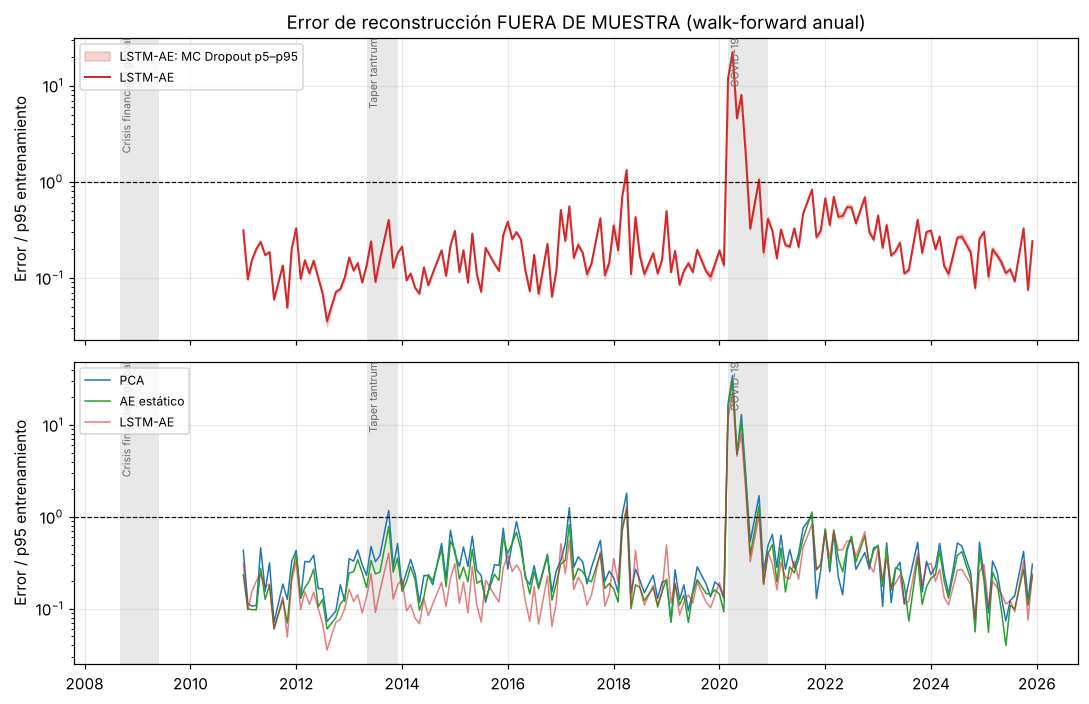

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)
ax = axes[0]
ax.fill_between(wf.index, wf['lstm_p05'], wf['lstm_p95'], color='tab:red', alpha=0.2, label='LSTM-AE: MC Dropout p5–p95')
ax.plot(wf.index, wf['lstm'], color='tab:red', lw=1.3, label='LSTM-AE')
ax.axhline(1, color='k', lw=0.8, ls='--')
ax.set_yscale('log'); ax.set_ylabel('Error / p95 entrenamiento'); ax.legend(fontsize=8, loc='upper left')
sombrear_episodios(ax)
ax.set_title('Error de reconstrucción FUERA DE MUESTRA (walk-forward anual)')
ax = axes[1]
ax.plot(wf.index, wf['pca'], color='tab:blue', lw=1, label='PCA')
ax.plot(wf.index, wf['ae'], color='tab:green', lw=1, label='AE estático')
ax.plot(wf.index, wf['lstm'], color='tab:red', lw=1, alpha=0.6, label='LSTM-AE')
ax.axhline(1, color='k', lw=0.8, ls='--')
ax.set_yscale('log'); ax.set_ylabel('Error / p95 entrenamiento'); ax.legend(fontsize=8, loc='upper left')
sombrear_episodios(ax)
plt.tight_layout(); plt.savefig('reports/figures/09_walkforward.png'); plt.show()

### 2.1 ¿Qué método separa mejor los episodios de referencia?

Se compara la razón de error **dentro** de los episodios evaluables fuera de muestra
(taper tantrum 2013 y COVID-19 2020) contra el resto de meses. Un buen indicador debe
tener mediana alta en episodios y baja fuera de ellos; se reporta además la proporción
de meses del episodio que superan el umbral 1 (sensibilidad) y la proporción de meses
fuera de episodios que lo superan (tasa de falsas alarmas).

In [5]:
en_episodio = pd.Series(False, index=wf.index)
etiqueta = pd.Series('', index=wf.index)
for nombre, (ini, fin) in EPISODIOS_REFERENCIA.items():
    m = (wf.index >= ini) & (wf.index <= fin)
    en_episodio[m] = True
    etiqueta[m] = nombre

filas = []
for metodo in ['pca', 'ae', 'lstm']:
    fila = {'metodo': metodo,
            'mediana_fuera_de_episodios': wf.loc[~en_episodio, metodo].median(),
            'falsas_alarmas_%': 100 * (wf.loc[~en_episodio, metodo] > 1).mean()}
    for nombre in ['Taper tantrum', 'COVID-19']:
        v = wf.loc[etiqueta == nombre, metodo]
        fila[f'mediana_{nombre}'] = v.median()
        fila[f'sensibilidad_{nombre}_%'] = 100 * (v > 1).mean()
    filas.append(fila)
discrim = pd.DataFrame(filas).set_index('metodo').round(2)
discrim.to_csv('data/results/09_discriminacion_episodios.csv')
discrim.T

metodo,pca,ae,lstm
mediana_fuera_de_episodios,0.27,0.21,0.18
falsas_alarmas_%,2.68,1.34,0.67
mediana_Taper tantrum,0.38,0.25,0.16
sensibilidad_Taper tantrum_%,14.29,0.00,0.00
mediana_COVID-19,2.89,2.43,1.92
sensibilidad_COVID-19_%,66.67,66.67,66.67


## 3. Modelo de muestra completa y trayectoria latente

Para describir (no para validar) la trayectoria del sistema en todo el periodo se
entrena el LSTM-AE con la muestra completa. Como en el notebook 08, el código latente
solo está identificado salvo rotaciones: se rota por Procrustes contra los scores del PCA
del mismo mes para que los ejes sean comparables. Se entrenan 5 réplicas y se toma la
central (máximo RV promedio) para no depender de la semilla.

In [6]:
Xs = StandardScaler().fit_transform(df.values)
W = crear_ventanas(Xs, L)
fechas_z = df.index[L - 1:]
corte = int(len(W) * 0.85)
modelos, codigos = [], []
for s in range(5):
    fijar_semillas(500 + s)
    m = LSTMAutoencoder(p, 16, D, dropout=0.20)
    entrenar(m, W[:corte], W[corte:], semilla=500 + s, **HP_LSTM)
    m.eval()
    with torch.no_grad():
        codigos.append(m.codificar(a_tensor(W)).numpy())
    modelos.append(m)
rv = np.array([[coeficiente_rv(a, b) for b in codigos] for a in codigos])
central = int(np.argmax(rv.mean(axis=1)))
lstm_final = modelos[central]
scores_pca = PCA(D).fit_transform(Xs)[L - 1:]
Z_rot, _ = rotar_procrustes(codigos[central], scores_pca)
ae08 = pd.read_csv('data/results/08_ae_factores_y_error.csv', index_col=0, parse_dates=True)
print(f'RV entre réplicas LSTM (mediana): {np.median(rv[np.triu_indices(5, 1)]):.3f}')
print(f'RV LSTM-AE vs PCA:               {coeficiente_rv(codigos[central], scores_pca):.3f}')
print(f'RV LSTM-AE vs AE estático (08):  {coeficiente_rv(codigos[central], ae08.loc[fechas_z].iloc[:, :D].values):.3f}')

RV entre réplicas LSTM (mediana): 0.906
RV LSTM-AE vs PCA:               0.186
RV LSTM-AE vs AE estático (08):  0.261


In [7]:
corr_var = pd.DataFrame(np.corrcoef(Xs[L - 1:].T, Z_rot.T)[:p, p:], index=nombres,
                        columns=[f'LSTM{i+1}' for i in range(D)]).round(2)
corr_var.sort_values('LSTM1', key=np.abs, ascending=False)

,LSTM1,LSTM2,LSTM3
Tasa pasiva TIPMN,-0.60,0.36,-0.16
Tasa activa TAMN,-0.34,0.13,-0.21
IPC Lima,-0.33,0.18,-0.13
Tasa interbancaria,-0.30,0.20,-0.09
Tasa referencia BCRP,-0.28,0.15,-0.12
Liquidez M3,0.27,0.08,0.31
Liquidez M2,0.23,0.06,0.24
Liquidez M1,0.23,0.06,0.27
Crédito consumo,-0.21,0.38,0.20
Crédito empresarial,0.18,0.27,0.46


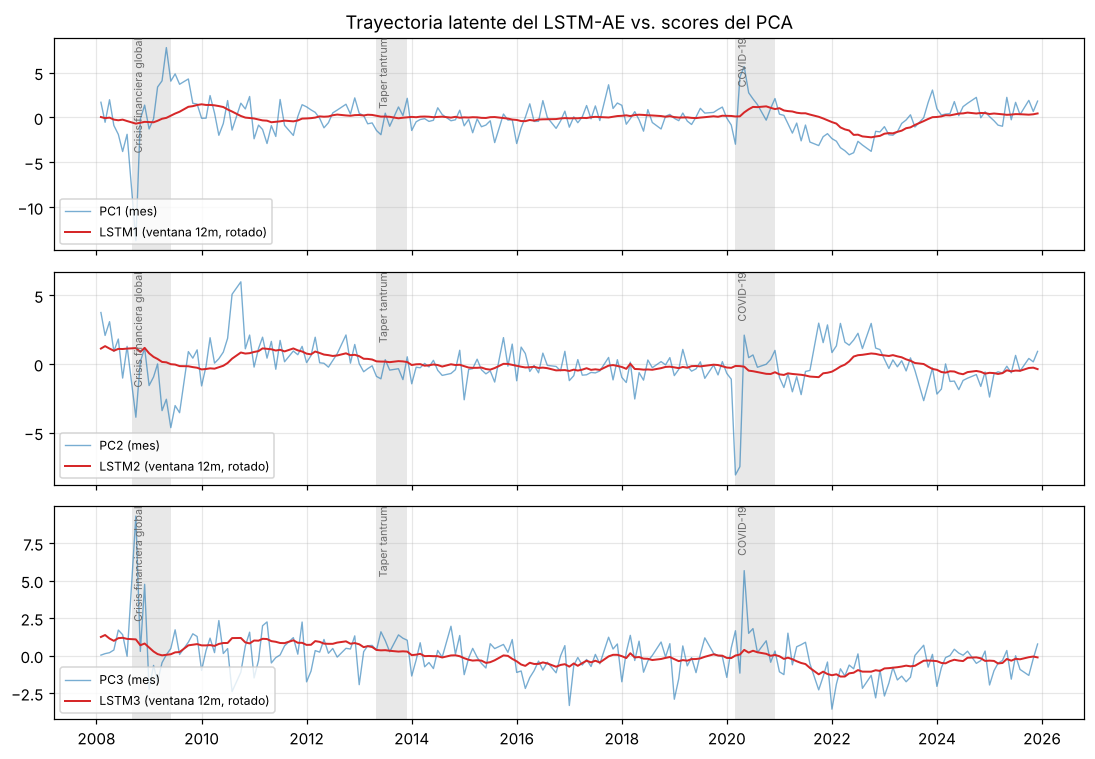

In [8]:
fig, axes = plt.subplots(D, 1, figsize=(10, 7), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(fechas_z, scores_pca[:, i], color='tab:blue', lw=0.9, alpha=0.6, label=f'PC{i+1} (mes)')
    ax.plot(fechas_z, Z_rot[:, i], color='tab:red', lw=1.3, label=f'LSTM{i+1} (ventana 12m, rotado)')
    ax.legend(fontsize=8, loc='lower left'); sombrear_episodios(ax)
axes[0].set_title('Trayectoria latente del LSTM-AE vs. scores del PCA')
plt.tight_layout(); plt.savefig('reports/figures/09_trayectoria_latente.png'); plt.show()

## 4. Datación de regímenes: partición óptima de Fisher

Sobre la trayectoria latente estandarizada (n − L + 1 = 197 meses × 3 ejes) se buscan
las particiones en k segmentos contiguos que minimizan la suma de cuadrados intra-segmento
(programación dinámica exacta), con longitud mínima de 12 meses por régimen.
El número de regímenes se elige con una regla de codo explícita: el menor k a partir del
cual pasar a k + 1 reduce la suma de cuadrados intra en menos de 10 %.

Como contraste, se aplica el mismo procedimiento a los scores del PCA.

In [9]:
def datar(Y, k_max=10, tam_min=12, umbral=0.10):
    Ys = StandardScaler().fit_transform(Y)
    res = particion_fisher(Ys, k_max=k_max, tam_min=tam_min)
    sce = pd.Series({k: v['sce'] for k, v in res.items()})
    reduccion = -sce.pct_change().shift(-1)        # reducción relativa al pasar de k a k+1
    k_opt = int(reduccion[reduccion < umbral].index.min())
    return res, sce, reduccion, k_opt

res_l, sce_l, red_l, k_l = datar(Z_rot)
res_p, sce_p, red_p, k_p = datar(scores_pca)
print(f'Regímenes elegidos — LSTM-AE: k = {k_l} | PCA: k = {k_p}')
pd.DataFrame({'SCE_LSTM': sce_l, 'reduccion_LSTM': red_l, 'SCE_PCA': sce_p, 'reduccion_PCA': red_p}).round(3)

Regímenes elegidos — LSTM-AE: k = 7 | PCA: k = 1


,SCE_LSTM,reduccion_LSTM,SCE_PCA,reduccion_PCA
1,591.000,0.387,591.000,0.046
2,362.374,0.114,563.687,0.096
3,321.038,0.371,509.845,0.039
4,201.933,0.109,490.215,0.063
5,179.973,0.243,459.519,0.052
6,136.245,0.182,435.578,0.025
7,111.509,0.094,424.697,0.012
8,101.040,0.098,419.618,0.010
9,91.169,0.054,415.223,0.009
10,86.261,NaN,411.301,NaN


### 4.1 Control: ¿la persistencia viene del modelo o de la ventana?

El código del LSTM resume 12 meses, por lo que es mecánicamente más suave que un score
mensual de PCA. Para no atribuir al LSTM una persistencia que solo proviene del promediado,
se repite la datación sobre la **media móvil de 12 meses** de los scores del PCA (misma
información temporal, sin no linealidad ni memoria aprendida).

In [10]:
scores_pca_mm = pd.DataFrame(PCA(D).fit_transform(Xs), index=df.index).rolling(L).mean().iloc[L - 1:].values
res_m, sce_m, red_m, k_m = datar(scores_pca_mm)
print(f'PCA suavizado (MM12): k = {k_m}')
print('Cortes PCA-MM12:', [fechas_z[c].strftime('%Y-%m') for c in res_m[k_m]['cortes']])
print(f'RV LSTM-AE vs PCA-MM12: {coeficiente_rv(codigos[central], scores_pca_mm):.3f}')

PCA suavizado (MM12): k = 8
Cortes PCA-MM12: ['2009-06', '2010-08', '2013-04', '2016-04', '2020-03', '2021-12', '2023-12']
RV LSTM-AE vs PCA-MM12: 0.798


In [11]:
def tabla_segmentos(cortes, fechas):
    bordes = [0] + list(cortes) + [len(fechas)]
    return [(fechas[a], fechas[b - 1]) for a, b in zip(bordes[:-1], bordes[1:])]

seg_l = tabla_segmentos(res_l[k_l]['cortes'], fechas_z)
seg_p = tabla_segmentos(res_p[k_p]['cortes'], fechas_z)
print('Cortes LSTM-AE:', [fechas_z[c].strftime('%Y-%m') for c in res_l[k_l]['cortes']])
print('Cortes PCA:    ', [fechas_z[c].strftime('%Y-%m') for c in res_p[k_p]['cortes']])

Cortes LSTM-AE: ['2009-04', '2010-08', '2013-05', '2020-06', '2022-02', '2023-10']
Cortes PCA:     []


## 5. Clasificación preliminar de fases

**Regla operativa (propuesta para discusión con el asesor, no definitiva):** cada
régimen de Fisher se caracteriza por el promedio, dentro del segmento, de un
**componente de crédito** = media de las tasas de crecimiento estandarizadas del crédito
empresarial, de consumo e hipotecario (variables núcleo del ciclo financiero en
Drehmann, Borio & Tsatsaronis, 2012).

- **Expansión:** promedio > +0,25 desviaciones estándar
- **Contracción:** promedio < −0,25 desviaciones estándar
- **Transición:** |promedio| ≤ 0,25, o segmento de menos de 18 meses

El umbral de 0,25 y la duración mínima son parámetros arbitrarios y deben someterse a
análisis de sensibilidad antes de cualquier conclusión. La clasificación solo usa el
crecimiento del crédito para **etiquetar** segmentos que fueron definidos por toda la
estructura latente; no participa en la segmentación.

In [12]:
cols_credito = [c for c in df.columns if c.startswith('Crédito')]
comp_credito = pd.Series(StandardScaler().fit_transform(df[cols_credito]).mean(axis=1), index=df.index)

def clasificar(segmentos, umbral=0.25, dur_min=18):
    filas = []
    for ini, fin in segmentos:
        v = comp_credito.loc[ini:fin]
        dur = len(v)
        m = v.mean()
        if dur < dur_min or abs(m) <= umbral:
            fase = 'Transición'
        else:
            fase = 'Expansión' if m > 0 else 'Contracción'
        episodios = [e for e, (a, b) in EPISODIOS_REFERENCIA.items()
                     if pd.Timestamp(a) <= fin and pd.Timestamp(b) >= ini]
        filas.append({'inicio': ini.strftime('%Y-%m'), 'fin': fin.strftime('%Y-%m'), 'meses': dur,
                      'componente_credito_medio': round(m, 2), 'fase': fase,
                      'episodios_contenidos': ', '.join(episodios)})
    return pd.DataFrame(filas)

fases_lstm = clasificar(seg_l)
fases_pca = clasificar(tabla_segmentos(res_m[k_m]['cortes'], fechas_z))  # se usa el PCA suavizado (control justo)
fases_lstm.to_csv('data/results/09_regimenes_lstm.csv', index=False)
fases_pca.to_csv('data/results/09_regimenes_pca.csv', index=False)
print('Regímenes LSTM-AE'); display(fases_lstm)
print('Regímenes PCA suavizado (MM12)'); display(fases_pca)

Regímenes LSTM-AE


,inicio,fin,meses,componente_credito_medio,fase,episodios_contenidos
0,2008-02,2009-03,13,0.76,Transición,Crisis financiera global
1,2009-04,2010-07,15,0.15,Transición,Crisis financiera global
2,2010-08,2013-04,30,0.55,Expansión,
3,2013-05,2020-05,78,-0.17,Transición,"Taper tantrum, COVID-19"
4,2020-06,2022-01,18,-0.51,Contracción,COVID-19
5,2022-02,2023-08,18,-0.31,Contracción,
6,2023-10,2025-12,25,-0.51,Contracción,


Regímenes PCA suavizado (MM12)


,inicio,fin,meses,componente_credito_medio,fase,episodios_contenidos
0,2008-02,2009-05,15,0.63,Transición,Crisis financiera global
1,2009-06,2010-07,13,0.21,Transición,Crisis financiera global
2,2010-08,2013-03,29,0.57,Expansión,
3,2013-04,2016-03,33,-0.07,Transición,Taper tantrum
4,2016-04,2020-02,43,-0.24,Transición,
5,2020-03,2021-11,19,-0.48,Contracción,COVID-19
6,2021-12,2023-11,22,-0.32,Contracción,
7,2023-12,2025-12,23,-0.52,Contracción,


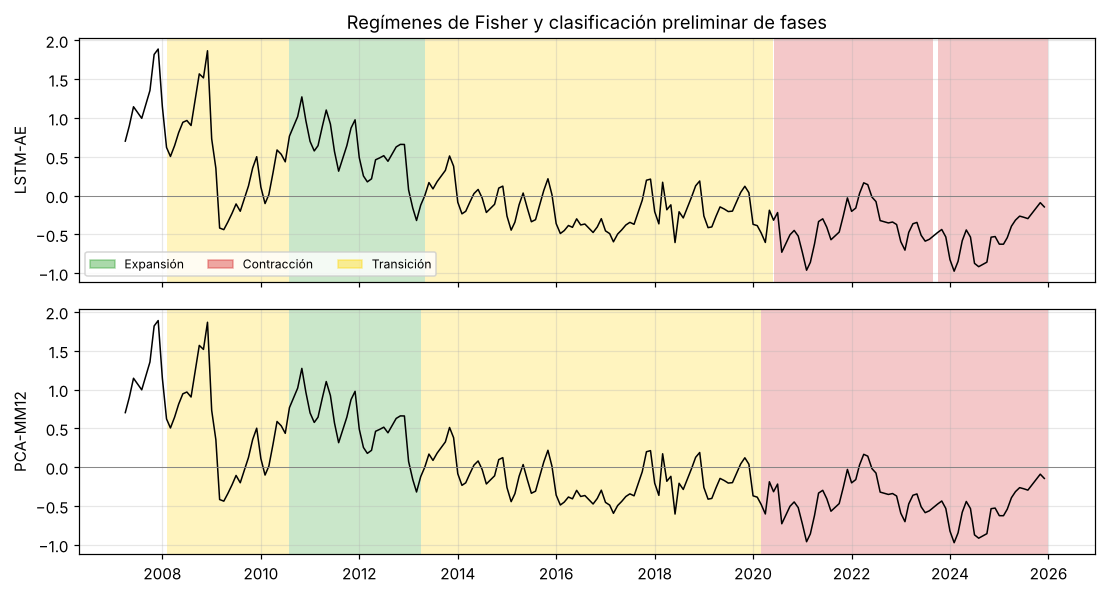

In [13]:
colores = {'Expansión': 'tab:green', 'Contracción': 'tab:red', 'Transición': 'gold'}
fig, axes = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)
for ax, fases, titulo in [(axes[0], fases_lstm, 'LSTM-AE'), (axes[1], fases_pca, 'PCA-MM12')]:
    ax.plot(comp_credito.index, comp_credito.rolling(3).mean(), color='k', lw=1, label='Componente de crédito (MM3)')
    for _, f in fases.iterrows():
        ax.axvspan(pd.Timestamp(f['inicio']), pd.Timestamp(f['fin']) + pd.offsets.MonthEnd(0),
                   color=colores[f['fase']], alpha=0.25, lw=0)
    ax.set_ylabel(titulo); ax.axhline(0, color='grey', lw=0.6)
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color=c, alpha=0.4, label=f) for f, c in colores.items()], fontsize=8, loc='lower left', ncol=3)
axes[0].set_title('Regímenes de Fisher y clasificación preliminar de fases')
plt.tight_layout(); plt.savefig('reports/figures/09_regimenes.png'); plt.show()

## 6. Guardar resultados

In [14]:
pd.DataFrame(Z_rot, index=fechas_z, columns=[f'LSTM{i+1}_rotado' for i in range(D)]).to_csv('data/results/09_lstm_trayectoria_latente.csv')
corr_var.to_csv('data/results/09_lstm_correlaciones_variables.csv')
torch.save(lstm_final.state_dict(), 'data/results/09_lstm_modelo_final.pt')
print('Resultados guardados en data/results/09_*')

Resultados guardados en data/results/09_*


## 7. Conclusiones (provisionales — recalcular con el dataset corregido)

1. **Fuera de muestra, la ventaja del LSTM-AE es modesta.** Los tres métodos (PCA, AE y
   LSTM-AE) detectan el COVID-19 en el 67 % de sus meses. Ninguno detecta el taper tantrum.
   El LSTM-AE tiene la menor tasa de falsas alarmas (0,7 % frente a 2,7 % del PCA), pero
   también la menor magnitud de señal en los episodios.
2. **Estable, pero distinto del PCA mensual.** RV entre réplicas de 0,91. RV con los scores
   mensuales del PCA de solo 0,19, y de 0,80 con su media móvil de 12 meses: lo que el LSTM
   "agrega" es, sobre todo, integración temporal.
3. **La datación de regímenes se explica mayormente por el suavizado.** Fisher sobre el
   LSTM-AE da cortes en 2009-04, 2010-08, 2013-05, 2020-06, 2022-02 y 2023-10. Sobre el PCA
   suavizado da 2009-06, 2010-08, 2013-04, 2016-04, 2020-03, 2021-12 y 2023-12. Sin suavizar,
   el PCA no muestra segmentos persistentes (k = 1). Para atribuir la contribución al LSTM, la
   tesis deberá mostrar diferencias sustantivas frente a este control.
4. **Fases preliminares** (regla δ = 0,25 y duración mínima de 18 meses): expansión de
   2010-08 a 2013-04; transición de 2013-05 a 2020-05; contracción desde mediados de 2020.
   El segmento 2008–2009, con crédito alto, queda como transición solo por su duración. La
   regla necesita análisis de sensibilidad.
5. **La crisis de 2008–2009 no es evaluable fuera de muestra** con la base 2007–2025. Esto
   motiva metodológicamente la extensión hacia 1985 (`01b`, `04c`).